# House Rent Prediction
### Full Pipeline: Load → Clean → Engineer → Encode → Train → Evaluate
#The order to always remember:
#Load → Understand → Drop useless → Handle nulls → Remove/workOn outliers → Fix skew → Encode → Split → Scale → Train → #Evaluate

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# STEP 1 — LOAD DATA
# Always first. Understand what you're working with.
# ============================================================

df = pd.read_csv('House_Rent_Dataset.csv')
print('Shape:', df.shape)
df.head()

Shape: (4746, 12)


,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [7]:
# ============================================================
# STEP 2 — UNDERSTAND THE DATA
# Before touching anything, know your columns and types.
# ============================================================

df.info()        # column types, null counts
print()
df.describe()    # min, max, mean, quartiles for numeric columns

<class 'pandas.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Posted On          4746 non-null   str  
 1   BHK                4746 non-null   int64
 2   Rent               4746 non-null   int64
 3   Size               4746 non-null   int64
 4   Floor              4746 non-null   str  
 5   Area Type          4746 non-null   str  
 6   Area Locality      4746 non-null   str  
 7   City               4746 non-null   str  
 8   Furnishing Status  4746 non-null   str  
 9   Tenant Preferred   4746 non-null   str  
 10  Bathroom           4746 non-null   int64
 11  Point of Contact   4746 non-null   str  
dtypes: int64(4), str(8)
memory usage: 445.1 KB



,BHK,Rent,Size,Bathroom
count,4746.000000,4.746000e+03,4746.000000,4746.000000
mean,2.083860,3.499345e+04,967.490729,1.965866
std,0.832256,7.810641e+04,634.202328,0.884532
min,1.000000,1.200000e+03,10.000000,1.000000
25%,2.000000,1.000000e+04,550.000000,1.000000
50%,2.000000,1.600000e+04,850.000000,2.000000
75%,3.000000,3.300000e+04,1200.000000,2.000000
max,6.000000,3.500000e+06,8000.000000,10.000000


In [8]:
# ============================================================
# STEP 3 — CHECK MISSING VALUES
# Fix before doing anything else.
# This dataset has no nulls — but always check.
# ============================================================

print(df.isnull().sum())

Posted On            0
BHK                  0
Rent                 0
Size                 0
Floor                0
Area Type            0
Area Locality        0
City                 0
Furnishing Status    0
Tenant Preferred     0
Bathroom             0
Point of Contact     0
dtype: int64


In [9]:
# ============================================================
# STEP 4 — FEATURE ENGINEERING: Parse Floor column
# Floor is stored as messy string: '1 out of 3', 'Ground out of 2'
# We extract useful numbers BEFORE dropping the column.
# We do this before dropping because once dropped, info is gone.
# ============================================================

# Extract current floor number ('Ground' becomes 0)
df['Floor_num'] = df['Floor'].str.extract(r'^(\d+)').astype(float).fillna(0)

# Extract total floors in the building
df['Total_floors'] = df['Floor'].str.extract(r'out of (\d+)').astype(float)

# Floor ratio = which floor relative to total
# Example: floor 5 in a 6-floor building = 0.83 (high up)
#          floor 5 in a 50-floor building = 0.10 (low down)
# Raw floor number alone doesn't capture this context
df['Floor_ratio'] = df['Floor_num'] / df['Total_floors']

# Fill any NaN ratios with 0 (ground floor cases)
df['Floor_ratio'] = df['Floor_ratio'].fillna(0)

print(df[['Floor', 'Floor_num', 'Total_floors', 'Floor_ratio']].head(10))

             Floor  Floor_num  Total_floors  Floor_ratio
0  Ground out of 2        0.0           2.0     0.000000
1       1 out of 3        1.0           3.0     0.333333
2       1 out of 3        1.0           3.0     0.333333
3       1 out of 2        1.0           2.0     0.500000
4       1 out of 2        1.0           2.0     0.500000
5  Ground out of 1        0.0           1.0     0.000000
6  Ground out of 4        0.0           4.0     0.000000
7       1 out of 2        1.0           2.0     0.500000
8       1 out of 2        1.0           2.0     0.500000
9       1 out of 3        1.0           3.0     0.333333


In [10]:
# ============================================================
# STEP 5 — DROP USELESS COLUMNS
# Remove columns that won't help predict rent.
#
# Posted On  → just a listing date, no pattern useful for rent
# Area Locality → 2000+ unique values, too many to encode meaningfully
# Floor      → already extracted what we need into Floor_num,
#               Total_floors, Floor_ratio — raw string no longer needed
# ============================================================

df = df.drop(columns=['Posted On', 'Area Locality', 'Floor'])
print('Shape after dropping useless columns:', df.shape)
df.head()

Shape after dropping useless columns: (4746, 12)


,BHK,Rent,Size,Area Type,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact,Floor_num,Total_floors,Floor_ratio
0,2,10000,1100,Super Area,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner,0.0,2.0,0.000000
1,2,20000,800,Super Area,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner,1.0,3.0,0.333333
2,2,17000,1000,Super Area,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner,1.0,3.0,0.333333
3,2,10000,800,Super Area,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner,1.0,2.0,0.500000
4,2,7500,850,Carpet Area,Kolkata,Unfurnished,Bachelors,1,Contact Owner,1.0,2.0,0.500000


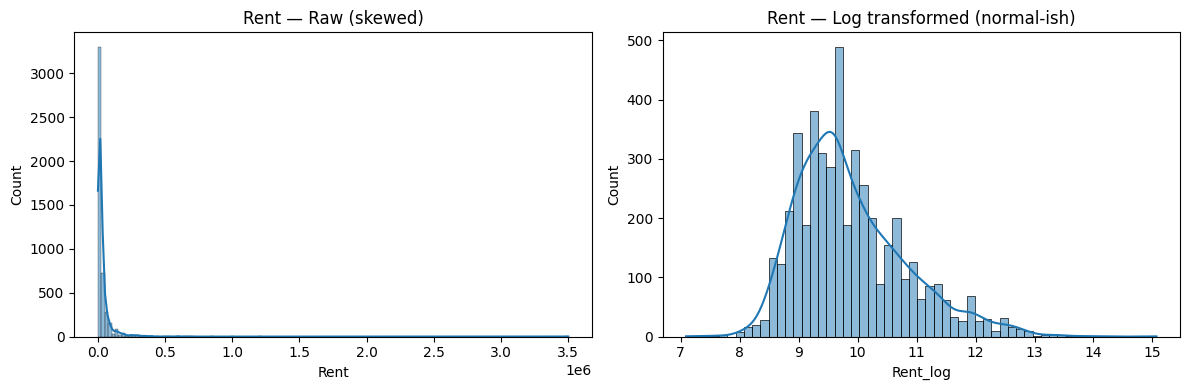

Rent_log created. Shape: (4746, 12)


In [11]:
# ============================================================
# STEP 6 — FIX SKEWED TARGET: Log Transform on Rent
# Rent is right-skewed — most are low, a few are huge (Trump Tower etc.)
# ML models struggle with skewed targets — predictions go wild.
# Log transform compresses the scale → makes distribution more normal.
#
# WHY NOT remove Rent outliers?
# Trump Tower Worli at Rs 3 lakhs is REAL data — removing it makes
# your model ignorant of luxury properties. Log transform keeps
# everything but reduces the impact of extremes.
# ============================================================

df['Rent_log'] = np.log1p(df['Rent'])  # log1p = log(1+x), safe for zero values

# Visualise before vs after
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['Rent'], kde=True, ax=axes[0])
axes[0].set_title('Rent — Raw (skewed)')
sns.histplot(df['Rent_log'], kde=True, ax=axes[1])
axes[1].set_title('Rent — Log transformed (normal-ish)')
plt.tight_layout()
plt.show()

# Drop raw Rent — we use Rent_log as our target
df = df.drop(columns=['Rent'])
print('Rent_log created. Shape:', df.shape)

In [12]:
# ============================================================
# STEP 7 — REMOVE OUTLIERS (domain logic, not blind IQR)
#
# WHY NOT use IQR for everything?
# IQR is blind — it removed Trump Tower Worli (Rs 3L, real property).
# Instead, use domain knowledge: what is actually IMPOSSIBLE?
#
# Size rule: Size per BHK should not exceed 1500 sqft
# A 1BHK of 8000 sqft is a data entry error — no 1BHK is 8000 sqft.
# A 4BHK of 5000 sqft is fine — large bungalow.
#
# Bathroom rule: Bathrooms should not exceed BHK + 2
# A 1BHK with 6 bathrooms is impossible.
# A 4BHK with 5 bathrooms is fine.
# ============================================================

before = df.shape[0]

# Remove impossible Size entries
df = df[df['Size'] / df['BHK'] <= 1500]

# Remove impossible Bathroom entries
df = df[df['Bathroom'] <= df['BHK'] + 2]

after = df.shape[0]
print(f'Rows removed: {before - after}')
print(f'Rows remaining: {after}')

Rows removed: 9
Rows remaining: 4737


In [13]:
# ============================================================
# STEP 8 — ENCODE CATEGORICAL COLUMNS
# ML models only understand numbers, not text.
#
# Two strategies:
# Label Encoding  → column has natural ORDER (bad=0, ok=1, good=2)
# One-Hot Encoding → column has NO order (Mumbai ≠ Delhi, just different)
# ============================================================

# --- Label Encoding: Furnishing Status (has order) ---
# Unfurnished < Semi-Furnished < Furnished — clear progression
furnishing_map = {'Unfurnished': 0, 'Semi-Furnished': 1, 'Furnished': 2}
df['Furnishing Status'] = df['Furnishing Status'].map(furnishing_map)

# --- One-Hot Encoding: columns with no natural order ---
# pd.get_dummies creates one new binary column per unique value
# drop_first=True removes one column to avoid redundancy
# (if we know Mumbai=0, Delhi=0, Bangalore=0, Chennai=0, Hyderabad=0
#  then it MUST be Kolkata — so we don't need the Kolkata column)
df = pd.get_dummies(
    df,
    columns=['City', 'Area Type', 'Tenant Preferred', 'Point of Contact'],
    drop_first=True
)

print('Shape after encoding:', df.shape)
df.head()

Shape after encoding: (4737, 19)


,BHK,Size,Furnishing Status,Bathroom,Floor_num,Total_floors,Floor_ratio,Rent_log,City_Chennai,City_Delhi,City_Hyderabad,City_Kolkata,City_Mumbai,Area Type_Carpet Area,Area Type_Super Area,Tenant Preferred_Bachelors/Family,Tenant Preferred_Family,Point of Contact_Contact Builder,Point of Contact_Contact Owner
0,2,1100,0,2,0.0,2.0,0.000000,9.210440,False,False,False,True,False,False,True,True,False,False,True
1,2,800,1,1,1.0,3.0,0.333333,9.903538,False,False,False,True,False,False,True,True,False,False,True
2,2,1000,1,1,1.0,3.0,0.333333,9.741027,False,False,False,True,False,False,True,True,False,False,True
3,2,800,0,1,1.0,2.0,0.500000,9.210440,False,False,False,True,False,False,True,True,False,False,True
4,2,850,0,1,1.0,2.0,0.500000,8.922792,False,False,False,True,False,True,False,False,False,False,True


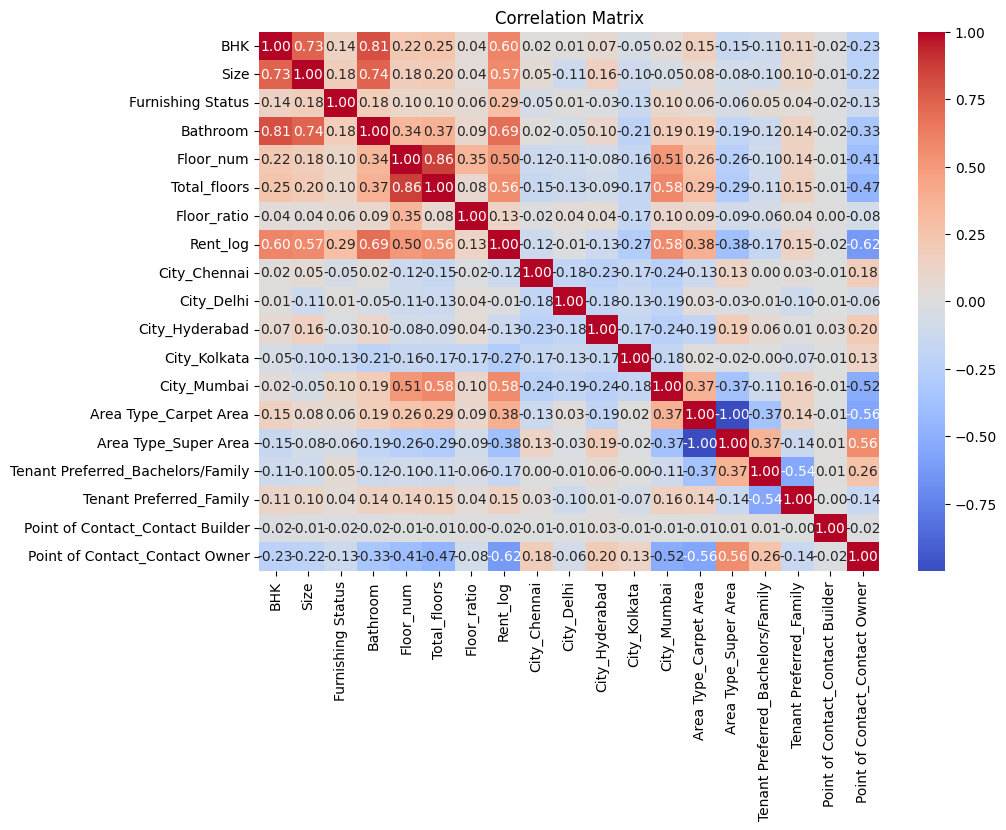

In [14]:
# ============================================================
# STEP 9 — EDA: Correlation Heatmap
# See which features are most related to Rent_log.
# This helps understand what the model will likely rely on.
# ============================================================

plt.figure(figsize=(10, 7))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True, fmt='.2f', cmap='coolwarm', center=0
)
plt.title('Correlation Matrix')
plt.show()

In [15]:
# Check where NaNs are
print(df.isnull().sum()[df.isnull().sum() > 0])

# Drop any remaining NaN rows
df = df.dropna()
print('Shape after dropping NaNs:', df.shape)

Total_floors    4
dtype: int64
Shape after dropping NaNs: (4733, 19)


In [16]:
# ============================================================
# STEP 10 — SPLIT INTO FEATURES AND TARGET
# X = everything the model learns FROM
# y = what the model is trying to PREDICT
# ============================================================

X = df.drop(columns=['Rent_log'])  # all columns except target
y = df['Rent_log']                 # target

print('Features shape:', X.shape)
print('Target shape:', y.shape)

Features shape: (4733, 18)
Target shape: (4733,)


In [17]:
# ============================================================
# STEP 11 — TRAIN / TEST SPLIT
# Never train and test on the same data — model will just memorise.
# 80% for training, 20% for testing.
# random_state=42 fixes the shuffle so results are reproducible.
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Train size:', X_train.shape)
print('Test size:', X_test.shape)

Train size: (3786, 18)
Test size: (947, 18)


In [18]:
# ============================================================
# STEP 12 — SCALE FEATURES
# StandardScaler brings all features to mean=0, std=1.
# Why? Size (1000 sqft) would dominate BHK (2) without scaling.
# Model would think Size is more important just because it's bigger.
#
# CRITICAL RULE:
# fit_transform on TRAIN → scaler learns mean/std from training data
# transform only on TEST → apply same scale, don't re-learn
# Fitting on test = data leakage (model sneaks a peek at future data)
# ============================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)   # learn from train, apply
X_test = scaler.transform(X_test)         # only apply, don't learn again

print('Scaling done.')

Scaling done.


In [19]:
# ============================================================
# STEP 13 — TRAIN MODEL
# Start with Linear Regression — always use simple model as baseline.
# If simple already works well, no need for complex ones.
# ============================================================

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)  # model finds best coefficients

print('Model trained.')

Model trained.


In [20]:
# ============================================================
# STEP 14 — EVALUATE
# R² score = how much variance the model explains
# 1.0 = perfect. 0.0 = no better than guessing the mean.
#
# MAE is in log scale here — to convert back to rupees:
# np.expm1(prediction) gives you back the actual rent value
# ============================================================

from sklearn.metrics import r2_score, mean_absolute_error

y_pred = model.predict(X_test)

r2  = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f'R² Score : {r2:.4f}')
print(f'MAE (log scale): {mae:.4f}')

# Convert MAE back to rupees for intuition
# This is approximate — gives sense of average error in actual rent
sample_pred_rupees = np.expm1(y_pred[:5])
sample_actual_rupees = np.expm1(y_test[:5])
print('\nSample predictions vs actual (in Rs):')
for pred, actual in zip(sample_pred_rupees, sample_actual_rupees):
    print(f'  Predicted: {pred:,.0f}  |  Actual: {actual:,.0f}')

R² Score : 0.7981
MAE (log scale): 0.3111

Sample predictions vs actual (in Rs):
  Predicted: 13,297  |  Actual: 11,000
  Predicted: 13,986  |  Actual: 13,000
  Predicted: 104,374  |  Actual: 100,000
  Predicted: 14,846  |  Actual: 13,000
  Predicted: 10,639  |  Actual: 12,000


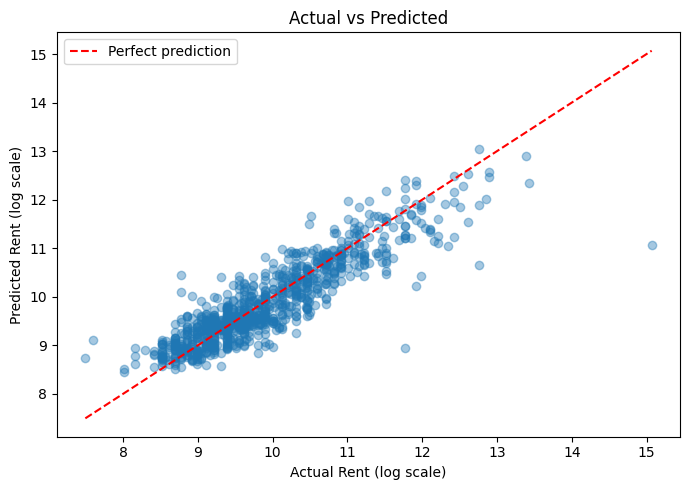

In [21]:
# ============================================================
# STEP 15 — VISUALISE PREDICTIONS
# Scatter plot of actual vs predicted.
# Perfect model = all points on the diagonal line.
# ============================================================

plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', label='Perfect prediction')
plt.xlabel('Actual Rent (log scale)')
plt.ylabel('Predicted Rent (log scale)')
plt.title('Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print(f'R² Score : {r2_score(y_test, y_pred_rf):.4f}')
print(f'MAE (log scale): {mean_absolute_error(y_test, y_pred_rf):.4f}')

R² Score : 0.8051
MAE (log scale): 0.3055


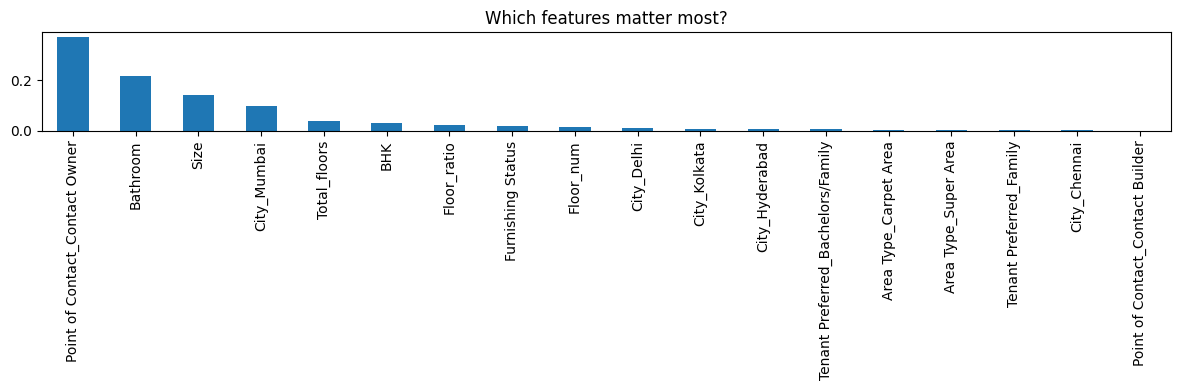

In [23]:
import pandas as pd

feature_names = df.drop(columns=['Rent_log']).columns

importances = pd.Series(rf_model.feature_importances_, index=feature_names)
importances.sort_values(ascending=False).plot(kind='bar', figsize=(12, 4))
plt.title('Which features matter most?')
plt.tight_layout()
plt.show()

In [24]:
# ============================================================
# IMPROVEMENT 1 — New features from existing columns
# The model currently sees Size and BHK separately.
# Size per room gives more context — a 1000sqft 2BHK vs 1000sqft 4BHK
# are very different properties.
# ============================================================

# Reload from your cleaned df (before train/test split)
df['Size_per_BHK'] = df['Size'] / df['BHK']
df['Bath_per_BHK'] = df['Bathroom'] / df['BHK']

In [25]:
# ============================================================
# IMPROVEMENT 2 — Rebuild X and y with new features, retrain
# ============================================================

X = df.drop(columns=['Rent_log'])
y = df['Rent_log']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# No scaler needed here

rf_model2 = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model2.fit(X_train, y_train)

y_pred2 = rf_model2.predict(X_test)

print(f'Old R²: 0.8051')
print(f'New R²: {r2_score(y_test, y_pred2):.4f}')
print(f'New MAE: {mean_absolute_error(y_test, y_pred2):.4f}')

Old R²: 0.8051
New R²: 0.8056
New MAE: 0.3061


In [26]:
# ============================================================
# TARGET ENCODING for Area Locality
# Instead of creating 2000 columns, replace each locality
# with the average Rent_log of that locality.
# Example: 'Whitefield' → 10.2 (average log rent there)
# This captures location value in just ONE column.
# ============================================================

# Reload fresh data to add locality back
df2 = pd.read_csv('House_Rent_Dataset.csv')

# Apply same cleaning as before
df2['Floor_num'] = df2['Floor'].str.extract(r'^(\d+)').astype(float).fillna(0)
df2['Total_floors'] = df2['Floor'].str.extract(r'out of (\d+)').astype(float)
df2['Floor_ratio'] = (df2['Floor_num'] / df2['Total_floors']).fillna(0)
df2 = df2.drop(columns=['Posted On', 'Floor'])
df2['Rent_log'] = np.log1p(df2['Rent'])
df2 = df2.drop(columns=['Rent'])
df2 = df2[df2['Size'] / df2['BHK'] <= 1500]
df2 = df2[df2['Bathroom'] <= df2['BHK'] + 2]
df2['Size_per_BHK'] = df2['Size'] / df2['BHK']
df2['Bath_per_BHK'] = df2['Bathroom'] / df2['BHK']

# Target encode Area Locality
locality_avg = df2.groupby('Area Locality')['Rent_log'].mean()
df2['Locality_encoded'] = df2['Area Locality'].map(locality_avg)
df2 = df2.drop(columns=['Area Locality'])

# Encode rest of categoricals
furnishing_map = {'Unfurnished': 0, 'Semi-Furnished': 1, 'Furnished': 2}
df2['Furnishing Status'] = df2['Furnishing Status'].map(furnishing_map)
df2 = pd.get_dummies(df2, columns=['City', 'Area Type', 'Tenant Preferred', 'Point of Contact'], drop_first=True)

df2 = df2.dropna()
print('Shape:', df2.shape)

Shape: (4733, 22)


In [27]:
# Train and compare
X2 = df2.drop(columns=['Rent_log'])
y2 = df2['Rent_log']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

rf_model3 = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model3.fit(X2_train, y2_train)

y_pred3 = rf_model3.predict(X2_test)

print(f'Without locality R²: 0.8056')
print(f'With locality R²:    {r2_score(y2_test, y_pred3):.4f}')
print(f'New MAE: {mean_absolute_error(y2_test, y_pred3):.4f}')

Without locality R²: 0.8056
With locality R²:    0.9022
New MAE: 0.1943


## ⚠️ Data Leakage Warning — What We Did Wrong Above

In the previous target encoding cells, we calculated the average rent using the **entire dataset** (including test rows), then trained and tested on that same data.

This is called **Data Leakage** — the model already has rent information baked into the features before predicting. That is why the score jumped so dramatically from 0.80 → 0.90. Part of that jump is genuine, part of it is leakage.

**The correct way:** Calculate locality averages from TRAINING data only, then apply those averages to test data. Test data should never influence any transformation.

The cell below fixes this properly.

In [28]:
# ============================================================
# CORRECT TARGET ENCODING — No Data Leakage
#
# WRONG way (what we did above):
# locality_avg = entire_df.groupby(locality)[rent].mean()
# → test rows influence the encoding → model already knows the answer
#
# RIGHT way:
# Split FIRST → calculate avg from TRAIN only → apply to both
# Test data uses train averages — never influences the encoding
# ============================================================

# Reload and clean fresh
df3 = pd.read_csv('House_Rent_Dataset.csv')

df3['Floor_num'] = df3['Floor'].str.extract(r'^(\d+)').astype(float).fillna(0)
df3['Total_floors'] = df3['Floor'].str.extract(r'out of (\d+)').astype(float)
df3['Floor_ratio'] = (df3['Floor_num'] / df3['Total_floors']).fillna(0)
df3 = df3.drop(columns=['Posted On', 'Floor'])
df3['Rent_log'] = np.log1p(df3['Rent'])
df3 = df3.drop(columns=['Rent'])
df3 = df3[df3['Size'] / df3['BHK'] <= 1500]
df3 = df3[df3['Bathroom'] <= df3['BHK'] + 2]
df3['Size_per_BHK'] = df3['Size'] / df3['BHK']
df3['Bath_per_BHK'] = df3['Bathroom'] / df3['BHK']

# Encode other categoricals
furnishing_map = {'Unfurnished': 0, 'Semi-Furnished': 1, 'Furnished': 2}
df3['Furnishing Status'] = df3['Furnishing Status'].map(furnishing_map)
df3 = pd.get_dummies(df3, columns=['City', 'Area Type', 'Tenant Preferred', 'Point of Contact'], drop_first=True)
df3 = df3.dropna()

# STEP 1 — Split FIRST before any locality encoding
X3 = df3.drop(columns=['Rent_log', 'Area Locality'])
y3 = df3['Rent_log']
locality_col = df3['Area Locality']

X3_train, X3_test, y3_train, y3_test, loc_train, loc_test = train_test_split(
    X3, y3, locality_col, test_size=0.2, random_state=42
)

# STEP 2 — Calculate locality average from TRAIN only
locality_avg_train = y3_train.groupby(loc_train).mean()

# STEP 3 — Apply to both using train averages only
# Unseen localities in test → fill with overall train mean
global_mean = y3_train.mean()
X3_train['Locality_encoded'] = loc_train.map(locality_avg_train).fillna(global_mean)
X3_test['Locality_encoded'] = loc_test.map(locality_avg_train).fillna(global_mean)

# STEP 4 — Train and evaluate
rf_model4 = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model4.fit(X3_train, y3_train)
y_pred4 = rf_model4.predict(X3_test)

print(f'Leaky R²   (wrong way): 0.9022')
print(f'Correct R² (right way): {r2_score(y3_test, y_pred4):.4f}')
print(f'MAE: {mean_absolute_error(y3_test, y_pred4):.4f}')
print()
print("The correct score is the honest one — this is what your model actually achieves.")


Leaky R²   (wrong way): 0.9022
Correct R² (right way): 0.6330
MAE: 0.4053

The correct score is the honest one — this is what your model actually achieves.


## Summary
- Dataset: House Rent across 6 Indian cities
- Target: Predict rent using property features
- Key decisions:
  - Used log transform on Rent instead of removing outliers
  - Removed impossible Size/Bathroom combos using domain logic
  - Tried target encoding for Area Locality — caused data leakage when done wrong
  - Correct target encoding actually hurt the score (data too sparse per locality)
  - Final model: Random Forest without locality encoding
- Final honest R²: 0.80